## **Crypto Statistical Arbitrage via Cointegration and Regime Filtering**

### Research Framework

#### **Objective**
Discover cointegrated crypto baskets that exhibit stable, regime-aware mean-reverting relationships, and combine them into a portfolio that generates strong risk-adjusted returns, evaluated via out-of-sample testing.

---

#### **Step 1 — Walk-Forward Backtest**
To avoid overfitting, the entire history was split into rolling **365-day train windows** and **60-day test windows**, stepped forward sequentially.  
Within each train window:

- **Basket Discovery** — Johansen cointegration was applied across all candidate baskets (2–4 assets). Only baskets with exactly one cointegrating relationship (**rank = 1**) were retained.  

- **Quality Filtering** — Surviving baskets were passed through a sequential pipeline:
  - ADF stationarity  
  - Variance ratio (mean-reversion check)  
  - Half-life between 2–15 days (estimated via OLS)  
  - Rolling half-life stability  
  - Spread predictability  

- **Parameter Calibration** — Since mean-reversion speed varies across time, key parameters were calibrated within each train window.  
  In particular, the **half-life lookback window** used in signal construction was scaled based on the **median half-life of the filtered baskets**.  
  This ensures that the signal adapts to the prevailing market regime, rather than relying on fixed global parameters.

- **Dynamic Cointegrating Weights** — Rolling cointegration weights were computed to allow hedge ratios to adapt to slow structural drift, with weights forward-filled to ensure no look-ahead bias.  

- **Alpha & Regime Signal** — An Ornstein-Uhlenbeck mean-reversion signal was computed on the dynamic spread, with clipping and deadbanding to suppress noise.  
  A two-tier regime filter was applied:
  - **Hard filters**: volatility spikes and ADF breakdown (signal = 0)  
  - **Soft score**: continuous weighting based on mean-reversion strength, stationarity quality, and volatility stability  

---

#### **Step 2 — Basket Scoring & Selection**
After all walk-forward folds, each basket was evaluated using **per-basket PnL attribution** to ensure accurate contribution measurement.

- Baskets were scored using a composite metric combining:
  - Mean fold Sharpe  
  - Consistency across folds  
  - Number of fold appearances  

- Baskets were filtered to those that:
  - Appeared in at least **2 folds**  
  - Had both **minimum and mean Sharpe > 0** across folds  

- A greedy diversification step was then applied, capping each asset to at most **2 baskets** to ensure diversification.  

---

#### **Step 3 — Out-of-Sample Testing**
The selected baskets were traded on a fully held-out **20% test set**.

- **Execution** — Positions were sized using a **bucketed framework** (e.g., flat / partial / full exposure), where trades occur only when alpha crosses bucket boundaries, significantly reducing turnover.  

- **Portfolio Construction** — Capital was allocated using **inverse-volatility risk parity**, based on trailing 30-day basket returns.  

- **Transaction Costs** — ~20 bps transaction costs were applied **only on signal-driven position changes**.

<img src="../artifacts/crypto_pipeline_detailed.svg" style="width: 40%;">

### 1. Setup & Imports

In [1]:
from binance.client import Client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from scipy.optimize import minimize
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

### 2. Constants & Hyperparameters

In [2]:
# ── Data & Spread ──────────────────────────────────────────────────────────────
MIN_HALF_LIFE = 2          # minimum acceptable half-life (days)
MAX_HALF_LIFE = 15         # maximum acceptable half-life (days)
HL_WINDOW     = 120        # lookback (bars) for rolling OU parameter estimation
REGIME_WINDOW = 30         # lookback (bars) for regime vol and ADF checks

# ── OU Signal ─────────────────────────────────────────────────────────────────
ALPHA_CLIP     = 3.0       # winsorise raw alpha to ±3σ
ALPHA_DEADBAND = 0.10      # zero out alpha below this

# ── Regime Filter ─────────────────────────────────────────────────────────────
# Tier 1 — hard kill: either condition triggers immediate alpha = 0
HARD_VOL_RATIO = 4.0       # short-term vol / long-term vol > this → structural break
HARD_ADF_PVAL  = 0.40      # rolling ADF p-value > this → spread non-stationary

# Tier 2 — soft score weights (must sum to 1.0)
REGIME_W_KAPPA = 0.35      # mean reversion speed
REGIME_W_ADF   = 0.35      # stationarity quality
REGIME_W_VOL   = 0.30      # volatility sanity

# ── Position Sizing ───────────────────────────────────────────────────────────
ENTRY_THRESHOLD = 0.08     # minimum alpha to open a position
EXIT_THRESHOLD  = 0.02     # alpha below this → exit
MAX_POS_SIZE    = 1.0      # maximum position size
MIN_POS_SIZE    = 0.10     # minimum position size

# ── Risk Parity ───────────────────────────────────────────────────────────────
VOL_WINDOW = 30            # trailing bars for per-basket volatility estimation
VOL_FLOOR  = 1e-6          # prevents division by zero for near-constant spreads

# ── Basket Selection ──────────────────────────────────────────────────────────
MIN_FOLDS    = 2           # basket must appear in at least this many WF folds
MIN_MEAN_SR  = 0.0         # mean fold Sharpe must be positive
MIN_FLOOR_SR = 0.0         # worst single fold Sharpe must be non-negative
N_SELECT     = 8           # max baskets after greedy diversification

# ── OOS Deployment ────────────────────────────────────────────────────────────
BUCKET_THRESHOLDS = [0.08, 0.10]    # alpha boundaries for position buckets
BUCKET_SIZES      = [0.0, 0.5, 1.0] # position sizes: flat / half / full
TCOST_BPS         = 20.0            # round-trip transaction cost

### 3. Data Acquisition

#### 3.1 Download Prices

In [3]:
class BinanceDataLoader:
    def __init__(self):
        self.client = Client(tld='US')
 
    def get_klines(self, symbol, interval, start, end):
        klines = self.client.get_historical_klines(symbol, interval, start, end)
        df = pd.DataFrame(klines, columns=[
            "open_time", "open", "high", "low", "close", "volume",
            "close_time", "quote_asset_volume", "number_of_trades",
            "taker_buy_base", "taker_buy_quote", "ignore"
        ])
        df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
        df = df.set_index("open_time")
        df = df.astype(float)
        return df
 
    def download_prices(self, symbols, interval="1d",
                        start="1 Jan 2021", end="1 Mar 2026"):
        prices = {}
        for symbol in tqdm(symbols):
            try:
                df = self.get_klines(symbol, interval, start, end)
                prices[symbol] = df["close"]
            except Exception as e:
                print(f"Failed: {symbol} — {e}")
        prices = pd.DataFrame(prices).sort_index()
        return prices

In [4]:
symbols = [
    "BTCUSDT","ETHUSDT","SOLUSDT","BNBUSDT","XRPUSDT","ADAUSDT","AVAXUSDT","DOTUSDT","ATOMUSDT","LINKUSDT","LDOUSDT",
    "ARBUSDT","OPUSDT","FILUSDT","LTCUSDT","DOGEUSDT","FETUSDT","MATICUSDT","NEARUSDT","APTUSDT","SUIUSDT","MKRUSDT",
    "CRVUSDT"
]

loader = BinanceDataLoader()
prices = loader.download_prices(
    symbols,
    interval="1d",
    start="1 Mar 2023",
    end= '1 Mar 2026'
)

100%|██████████| 23/23 [00:07<00:00,  2.90it/s]


#### 3.2 Clean & Filter

In [5]:
threshold = int(0.05 * len(prices))
prices = prices.loc[:, prices.isna().sum() < threshold]
prices

,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,ADAUSDT,AVAXUSDT,DOTUSDT,ATOMUSDT,LINKUSDT,LDOUSDT,OPUSDT,FILUSDT,LTCUSDT,DOGEUSDT,FETUSDT,NEARUSDT,APTUSDT,CRVUSDT
open_time,,,,,,,,,,,,,,,,,,
2023-03-01,23629.08,1664.92,22.5147,302.5647,0.36042,17.75,6.520,12.781,7.540,3.040,2.770,7.280,97.68,0.081962,0.4838,2.324,13.4800,1.0370
2023-03-02,23468.02,1647.28,21.9753,299.8583,0.34933,17.46,6.330,12.450,7.230,3.019,2.723,6.920,95.18,0.080486,0.4663,2.239,12.8428,0.9900
2023-03-03,22358.06,1569.11,21.3900,290.4000,0.34290,16.66,6.036,12.011,6.952,2.813,2.540,6.228,90.43,0.076820,0.4391,2.094,11.7475,0.9360
2023-03-04,22346.68,1566.84,20.9800,289.6000,0.33630,16.13,5.910,11.838,6.850,2.549,2.363,5.904,89.33,0.074650,0.4292,2.042,11.2763,0.9060
2023-03-05,22430.68,1564.63,20.9900,288.6000,0.33660,16.18,5.975,12.030,6.914,2.602,2.427,6.110,89.94,0.074660,0.4320,2.026,11.0906,0.9240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-25,67957.93,2057.35,88.0300,625.4700,0.29580,9.50,1.639,1.930,9.200,0.294,0.123,1.091,56.59,0.099940,0.1656,1.173,1.0020,0.2516
2026-02-26,67481.40,2026.71,85.9300,625.9300,0.28690,9.30,1.643,1.901,9.110,0.302,0.117,1.033,55.43,0.097030,0.1625,1.130,0.9780,0.2484
2026-02-27,65882.98,1929.82,81.9800,614.2000,0.27710,8.94,1.603,1.876,8.680,0.292,0.120,0.975,54.55,0.093380,0.1559,1.098,0.9570,0.2421


#### 3.3 Train / Test Split

In [6]:
split_idx = int(len(prices) * 0.8)
prices_train = prices.iloc[:split_idx]
prices_test  = prices.iloc[split_idx:]

In [7]:
prices_train

,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,ADAUSDT,AVAXUSDT,DOTUSDT,ATOMUSDT,LINKUSDT,LDOUSDT,OPUSDT,FILUSDT,LTCUSDT,DOGEUSDT,FETUSDT,NEARUSDT,APTUSDT,CRVUSDT
open_time,,,,,,,,,,,,,,,,,,
2023-03-01,23629.08,1664.92,22.5147,302.5647,0.36042,17.75,6.520,12.781,7.540,3.040,2.770,7.280,97.68,0.081962,0.4838,2.324,13.4800,1.0370
2023-03-02,23468.02,1647.28,21.9753,299.8583,0.34933,17.46,6.330,12.450,7.230,3.019,2.723,6.920,95.18,0.080486,0.4663,2.239,12.8428,0.9900
2023-03-03,22358.06,1569.11,21.3900,290.4000,0.34290,16.66,6.036,12.011,6.952,2.813,2.540,6.228,90.43,0.076820,0.4391,2.094,11.7475,0.9360
2023-03-04,22346.68,1566.84,20.9800,289.6000,0.33630,16.13,5.910,11.838,6.850,2.549,2.363,5.904,89.33,0.074650,0.4292,2.042,11.2763,0.9060
2023-03-05,22430.68,1564.63,20.9900,288.6000,0.33660,16.18,5.975,12.030,6.914,2.602,2.427,6.110,89.94,0.074660,0.4320,2.026,11.0906,0.9240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-20,117232.91,3760.19,181.4600,757.4900,0.85710,25.12,4.445,5.196,19.290,1.241,0.793,2.859,116.88,0.273710,0.8000,2.986,5.2200,0.9558
2025-07-21,117480.91,3767.17,195.7300,766.3900,0.88970,25.56,4.473,5.203,19.530,1.190,0.807,2.897,115.52,0.271220,0.8420,3.038,5.4400,0.9779
2025-07-22,119999.61,3749.89,205.8500,783.7100,0.90210,25.87,4.519,5.120,19.660,1.220,0.800,2.932,119.48,0.270430,0.8240,3.028,5.4680,0.9796


In [8]:
prices_test

,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,ADAUSDT,AVAXUSDT,DOTUSDT,ATOMUSDT,LINKUSDT,LDOUSDT,OPUSDT,FILUSDT,LTCUSDT,DOGEUSDT,FETUSDT,NEARUSDT,APTUSDT,CRVUSDT
open_time,,,,,,,,,,,,,,,,,,
2025-07-25,117577.40,3720.94,186.58,784.57,0.8167,24.02,4.075,4.712,18.23,1.049,0.718,2.636,113.53,0.23617,0.7400,2.857,4.765,1.0229
2025-07-26,117850.00,3740.65,184.88,792.91,0.8202,24.91,4.124,4.770,18.41,1.098,0.725,2.658,113.96,0.23530,0.7310,2.895,4.849,1.1037
2025-07-27,119395.67,3873.34,188.56,842.39,0.8304,26.02,4.226,4.857,19.21,1.147,0.742,2.761,115.03,0.24056,0.7550,2.972,4.914,1.0437
2025-07-28,118080.54,3794.79,182.39,823.26,0.7898,25.19,3.941,4.609,18.05,1.068,0.755,2.592,108.93,0.22599,0.7180,2.774,4.692,1.0233
2025-07-29,117875.98,3794.85,181.61,804.75,0.7834,24.39,3.885,4.522,17.79,1.064,0.726,2.547,108.24,0.22300,0.7070,2.727,4.575,0.9713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-25,67957.93,2057.35,88.03,625.47,0.2958,9.50,1.639,1.930,9.20,0.294,0.123,1.091,56.59,0.09994,0.1656,1.173,1.002,0.2516
2026-02-26,67481.40,2026.71,85.93,625.93,0.2869,9.30,1.643,1.901,9.11,0.302,0.117,1.033,55.43,0.09703,0.1625,1.130,0.978,0.2484
2026-02-27,65882.98,1929.82,81.98,614.20,0.2771,8.94,1.603,1.876,8.68,0.292,0.120,0.975,54.55,0.09338,0.1559,1.098,0.957,0.2421


### 4. Basket Discovery

#### 4.1 Johansen Cointegration

In [9]:
def find_cointegrated_baskets(prices, symbols, min_size=2, max_size=3):
    """
    Enumerate all asset combinations of size [min_size, max_size] and return
    only those with exactly one cointegrating relationship (Johansen rank == 1).

    Parameters
    ----------
    prices   : pd.DataFrame — daily close prices, columns = asset symbols
    symbols  : list[str]    — universe of assets to enumerate over
    min_size : int          — minimum basket size (default 2)
    max_size : int          — maximum basket size (default 3)

    Returns
    -------
    list[dict] — each dict contains:
        assets  : tuple[str]  — asset names in the basket
        weights : np.ndarray  — normalised cointegrating vector
        trace   : float       — Johansen trace statistic (first eigenvalue)
        spread  : pd.Series   — log_prices @ weights (static, full-sample)

    """
    baskets = []
    for size in range(min_size, max_size + 1):
        for combo in combinations(symbols, size):
            subset = prices[list(combo)].dropna()
            if len(subset) < 200:
                continue
            log_prices = np.log(subset).replace([np.inf, -np.inf], np.nan).dropna()
            if len(log_prices) < 200:
                continue
            try:
                result = coint_johansen(log_prices, det_order=0, k_ar_diff=1)
            except np.linalg.LinAlgError:
                continue
 
            trace_stats = result.lr1
            crit_vals   = result.cvt[:, 1]
            rank        = sum(trace_stats > crit_vals)
            if rank != 1:
                continue
 
            weights = result.evec[:, 0]
            weights = weights / np.sum(np.abs(weights))
            if weights[0] < 0:
                weights = -weights
 
            spread = log_prices.dot(weights)
            baskets.append({
                "assets"  : combo,
                "weights" : weights,
                "trace"   : trace_stats[0],
                "spread"  : spread,
            })
    return baskets

#### 4.2 Spread Quality Filters

##### 4.2.1 ADF Stationarity

In [10]:
def check_spread_stationarity(spread: pd.Series) -> dict:
    """
    Test whether a spread is stationary using the Augmented Dickey-Fuller test.

    Parameters
    ----------
    spread : pd.Series — spread series (log price linear combination)

    Returns
    -------
    dict with keys:
        adf_pval      : float — ADF p-value rounded to 4dp
        adf_pass      : bool  — True if p-value < 0.05
        is_stationary : bool  — alias of adf_pass
    """
    s        = spread.dropna()
    adf_pval = adfuller(s, maxlag=1, autolag=None)[1]
    adf_pass = adf_pval < 0.05
    return {
        "adf_pval"     : round(adf_pval, 4),
        "adf_pass"     : adf_pass,
        "is_stationary": adf_pass,
    }

##### 4.2.2 Variance Ratio

In [11]:
def variance_ratio(spread, k=5):
    """
    Compute the variance ratio statistic to test for mean reversion.

    Parameters
    ----------
    spread : pd.Series — spread series
    k      : int       — horizon for multi-period variance (default 5 days)

    Returns
    -------
    float — variance ratio (< 1.0 = mean-reverting, > 1.0 = momentum)
    """
    s    = spread.dropna()
    var1 = np.var(s.diff().dropna())
    vark = np.var(s.diff(k).dropna())
    return vark / (k * var1)

##### 4.2.3 Half-Life & Stability

In [12]:
def estimate_half_life(spread: pd.Series) -> dict:
    """
    Estimate the mean-reversion half-life of a spread via OLS.

    Parameters
    ----------
    spread : pd.Series — spread series

    Returns
    -------
    dict with keys:
        half_life : float — mean-reversion half-life in days (np.inf if κ ≥ 0)
        kappa     : float — OLS mean-reversion speed coefficient
        r_squared : float — regression R² (signal quality indicator)
    """
    s     = spread.dropna()
    s_lag = s.shift(1).dropna()
    s_dif = s.diff().dropna()
    idx   = s_dif.index
 
    model = sm.OLS(s_dif.loc[idx], sm.add_constant(s_lag.loc[idx])).fit()
    kappa = model.params.iloc[1]
 
    if kappa >= 0:
        return {"half_life": np.inf, "kappa": kappa, "r_squared": model.rsquared}
 
    half_life = -np.log(2) / kappa
    return {
        "half_life" : round(half_life, 2),
        "kappa"     : round(kappa, 6),
        "r_squared" : round(model.rsquared, 4),
    }

def halflife_stability(spread, window=200, step=30):
    """
    Measure how stable the half-life estimate is over rolling sub-windows.

    Parameters
    ----------
    spread : pd.Series — spread series
    window : int       — rolling estimation window in bars (default 200)
    step   : int       — step size between estimates in bars (default 30)

    Returns
    -------
    float — coefficient of variation of rolling half-life estimates.
            Returns np.inf if fewer than 2 valid estimates exist, which
            correctly triggers the > 0.5 filter and rejects the basket.
    """
    rolling_hl = []
    for i in range(window, len(spread), step):
        hl = estimate_half_life(spread.iloc[i - window : i])["half_life"]
        if hl != np.inf:
            rolling_hl.append(hl)

    if len(rolling_hl) < 2:          
        return np.inf
    return np.std(rolling_hl) / np.mean(rolling_hl)

##### 4.2.4 Spread Predictability

In [13]:
def spread_predictability(spread, half_life):
    """
    Test whether the current z-score predicts future spread returns.

    Parameters
    ----------
    spread     : pd.Series — spread series
    half_life  : float     — estimated half-life, used as forecast horizon

    Returns
    -------
    dict with keys:
        beta      : float — regression coefficient of z-score on future returns
        tstat     : float — t-statistic of beta
        horizon   : int   — forecast horizon used (= int(half_life))
        r_squared : float — regression R²
    """
    s = spread.dropna()
    z = (s - s.mean()) / s.std()
    horizon = max(1, int(half_life))
    future_ret = s.diff(horizon).shift(-horizon)
    df = pd.DataFrame({"z": z, "future_ret": future_ret}).dropna()
    model = sm.OLS(df["future_ret"], sm.add_constant(df["z"])).fit()
    return {
        "beta"     : model.params["z"],
        "tstat"    : model.tvalues["z"],
        "horizon"  : horizon,
        "r_squared": model.rsquared,
    }

#### 4.3 Dynamic Spread Reconstruction

In [14]:
def rolling_coint_weights(prices, assets, window=180, step=30):
    """
    Re-estimate the Johansen cointegrating vector on a rolling walk-forward
    basis, returning one weight vector per re-estimation date.

    Parameters
    ----------
    prices : pd.DataFrame — daily close prices
    assets : tuple[str]   — basket assets (ordered, matches weight indices)
    window : int          — estimation window in bars (default 180 ≈ 6 months)
    step   : int          — re-estimation frequency in bars (default 30 ≈ 1 month)

    Returns
    -------
    pd.DataFrame — index = re-estimation dates, columns = asset names,
                   values = normalised cointegrating weights.
                   Empty DataFrame if no valid estimates were produced.
    """
    log_prices = np.log(prices[list(assets)]).dropna()
    records    = []
 
    for i in range(window, len(log_prices), step):
        window_data = log_prices.iloc[i - window : i]
        try:
            result = coint_johansen(window_data, det_order=0, k_ar_diff=1)
            rank   = sum(result.lr1 > result.cvt[:, 1])
            if rank < 1:
                continue
            w = result.evec[:, 0]
            w = w / np.sum(np.abs(w))
            if w[0] < 0:
                w = -w
            records.append({
                "date": log_prices.index[i],
                **{assets[j]: w[j] for j in range(len(assets))}
            })
        except Exception:
            continue
 
    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records).set_index("date")

In [15]:
def build_dynamic_spread(prices, assets, window=180, step=30):
    """
    Reconstruct a daily spread series using rolling cointegrating weights,
    ensuring no look-ahead at any point in the series.

    Parameters
    ----------
    prices : pd.DataFrame — daily close prices
    assets : tuple[str]   — basket assets
    window : int          — rolling estimation window in bars (default 180)
    step   : int          — re-estimation frequency in bars (default 30)

    Returns
    -------
    spread_dynamic : pd.Series   — daily dynamic spread aligned to price index,
                                   or None if insufficient valid estimates exist
    weights_latest : np.ndarray  — most recent cointegrating vector for OOS
                                   initialisation, or None on failure
    """
    log_prices = np.log(prices[list(assets)]).dropna()
    rolling_w  = rolling_coint_weights(prices, assets, window=window, step=step)
 
    if rolling_w.empty or len(rolling_w) < 2:
        return None, None
 
    weights_daily = rolling_w.reindex(log_prices.index).ffill().dropna()
    common_idx    = log_prices.index.intersection(weights_daily.index)
 
    if len(common_idx) < 200:
        return None, None
 
    lp_aligned     = log_prices.loc[common_idx]
    w_aligned      = weights_daily.loc[common_idx]
    spread_dynamic = (lp_aligned * w_aligned).sum(axis=1)
    weights_latest = rolling_w.iloc[-1].values
 
    return spread_dynamic, weights_latest

### 5. Signal Generation

#### 5.1 OU Alpha (Point & Series)

In [16]:
def compute_ou_alpha_point(
    spread_history: pd.Series,
    hl_window     : int = HL_WINDOW,
) -> dict:
    """
    Compute the Ornstein-Uhlenbeck alpha signal at a single point in time.

    Filters applied before returning:
        - Returns alpha=0 if fewer than hl_window+20 bars available (insufficient history)
        - Returns alpha=0 if half-life is infinite or outside [MIN_HALF_LIFE, MAX_HALF_LIFE]
          (spread not mean-reverting, or reverting too slowly/quickly to trade)
        - Returns alpha=0 if sigma < 1e-8 (degenerate/constant spread)
        - Winsorises raw alpha to [-ALPHA_CLIP, +ALPHA_CLIP] (default ±3.0)
        - Applies deadband: alpha set to 0 if |alpha| < ALPHA_DEADBAND (default 0.10)
          to avoid entering on negligible displacements

    Parameters
    ----------
    spread_history : pd.Series
        Full history of the spread up to and including the current bar.
        No future data — caller must slice to current index.
    hl_window : int
        Lookback (in bars) for half-life and kappa estimation.
        Defaults to HL_WINDOW (120). Calibrated per basket in OOS deployment.

    Returns
    -------
    dict with keys:
        alpha     : float — processed signal value, 0.0 if any filter triggered
        half_life : float — estimated half-life in days, np.nan if estimation failed
        kappa     : float — mean-reversion speed (negative = reverting), np.nan if failed
    """
    s = spread_history.dropna()
    if len(s) < hl_window + 20:
        return {"alpha": 0.0, "half_life": np.nan, "kappa": np.nan}
 
    hl_est = estimate_half_life(s.iloc[-hl_window:])
    hl     = hl_est["half_life"]
    kappa  = hl_est["kappa"]
 
    if hl == np.inf or not (MIN_HALF_LIFE <= hl <= MAX_HALF_LIFE):
        return {"alpha": 0.0, "half_life": hl, "kappa": kappa}
 
    bb_window = max(20, int(3 * hl))
    s_window  = s.iloc[-bb_window:]
    mu        = s_window.mean()
    sigma     = s_window.std()
 
    if sigma < 1e-8:
        return {"alpha": 0.0, "half_life": hl, "kappa": kappa}
 
    raw_alpha = abs(kappa) * (mu - s.iloc[-1]) / sigma
    alpha     = float(np.clip(raw_alpha, -ALPHA_CLIP, ALPHA_CLIP))
    if abs(alpha) < ALPHA_DEADBAND:
        alpha = 0.0
 
    return {"alpha": alpha, "half_life": hl, "kappa": kappa}

In [17]:
def compute_ou_alpha_series(
    spread    : pd.Series,
    hl_window : int = HL_WINDOW,
) -> pd.Series:
    """
    Compute the OU alpha signal for every bar in the spread history,
    strictly without look-ahead.

    Parameters
    ----------
    spread : pd.Series
        Full spread series (train + test concatenated). 
    hl_window : int
        Lookback for half-life and kappa estimation at each bar.
        Defaults to HL_WINDOW (120).

    Returns
    -------
    pd.Series
        Alpha values aligned to spread.index. Zero where:
        - bar is within the warmup period
        - any filter inside compute_ou_alpha_point triggered (HL out of
          range, sigma degenerate, deadband, winsorisation to zero)
        - spread had NaN at that bar
    """
    s      = spread.dropna()
    alphas = pd.Series(0.0, index=s.index)
    for i in range(hl_window + 20, len(s)):
        result         = compute_ou_alpha_point(s.iloc[: i + 1], hl_window)
        alphas.iloc[i] = result["alpha"]
    return alphas.reindex(spread.index).fillna(0.0)

#### 5.2 Two-Tier Regime Filter

In [18]:
def compute_regime_score_point(
    spread_history: pd.Series,
    hl            : float,
    window        : int = REGIME_WINDOW,
) -> float:
    """
    Compute the two-tier regime quality score for a spread at a single bar.

    Tier 1 — Hard kill (returns 0.0 immediately, no soft scoring attempted):
        vol_ratio > HARD_VOL_RATIO (default 4.0):
        adf_pval > HARD_ADF_PVAL (default 0.40):

    Tier 2 — Soft score (continuous, returned if both hard kills cleared):
        Three sub-scores, each clipped to [0, 1], combined as a weighted sum:

        kappa_score (weight REGIME_W_KAPPA, default 0.35):
            Measures local mean-reversion speed relative to the slowest
            acceptable rate

        adf_score (weight REGIME_W_ADF, default 0.35):
            Stationarity quality.

        vol_score (weight REGIME_W_VOL, default 0.30):
            Volatility sanity. score = clip(1 - vol_ratio / 2.5, 0, 1).

    Adaptive BB window:
        The local kappa estimation window is set to max(20, 3 × hl) when a
        valid half-life is available, otherwise falls back to window.

    Parameters
    ----------
    spread_history : pd.Series
        Spread history up to and including the current bar. No future data.
    hl : float
        Current half-life estimate passed in from compute_regime_score_series.
        Used to set the adaptive BB window. If np.nan or np.inf, falls back
        to window for the BB window size.
    window : int
        Base lookback for vol ratio computation (short-term window).
        Long-term window is 3 × this value. Defaults to REGIME_WINDOW (30).

    Returns
    -------
    float
        Score in [0, 1]. 0.0 if hard kill triggered or insufficient history
        (min bars = max(window * 4, 30)). Higher scores indicate a healthier
        mean-reversion regime.
    """
    s = spread_history.dropna()
 
    min_len = max(window * 4, 30)
    if len(s) < min_len:
        return 0.0
 
    s_dif = s.diff()
 
    # ── adaptive BB window ─────────────────────────────────
    bb_w = (max(20, int(3 * hl))
            if (hl not in (np.nan, np.inf) and hl > 0)
            else window)
 
    # ── Condition A: volatility ratio ─────────────────────
    sv       = s_dif.iloc[-window:].std()
    lv       = s_dif.iloc[-(window * 3):].std()
    vol_ratio = sv / lv if lv > 1e-8 else np.inf
 
    # Tier 1 hard kill: vol spike
    if vol_ratio > HARD_VOL_RATIO:
        return 0.0
 
    # ── Condition B: rolling ADF p-value ──────────────────
    adf_window = min(len(s), 90)
    try:
        adf_pval = adfuller(
            s.iloc[-adf_window:], maxlag=1, autolag=None
        )[1]
    except Exception:
        adf_pval = 1.0 
 
    if adf_pval > HARD_ADF_PVAL:
        return 0.0
 
    # ── Condition C: local kappa (mean reversion alive) ───
    s_kw = s.iloc[-bb_w:]
    sl_k = s_kw.shift(1).dropna()
    sd_k = s_kw.diff().dropna()
    cm_k = sl_k.index.intersection(sd_k.index)
 
    kappa_local = np.nan
    if len(cm_k) >= 20:
        try:
            mk          = sm.OLS(sd_k.loc[cm_k],
                                 sm.add_constant(sl_k.loc[cm_k]))
            kappa_local = mk.fit().params.iloc[1]
        except Exception:
            pass
 
    # ── Tier 2: Soft score ────────────────────────────────
    # kappa score: normalise by slowest acceptable speed
    kappa_ref   = np.log(2) / MAX_HALF_LIFE   
    kappa_score = 0.0
    if not np.isnan(kappa_local) and kappa_local < 0:
        kappa_score = float(np.clip(abs(kappa_local) / kappa_ref, 0.0, 1.0))
 
    # adf score: low p-value → high score
    adf_score = float(np.clip(1.0 - adf_pval / 0.15, 0.0, 1.0))
 
    # vol score: low vol_ratio → high score (cap ratio at 2.5)
    vol_score = float(np.clip(1.0 - vol_ratio / 2.5, 0.0, 1.0))
 
    score = (
        REGIME_W_KAPPA * kappa_score
        + REGIME_W_ADF * adf_score
        + REGIME_W_VOL * vol_score
    )
    return float(np.clip(score, 0.0, 1.0))

In [19]:
def compute_regime_score_series(
    spread    : pd.Series,
    hl_window : int = HL_WINDOW,
    window    : int = REGIME_WINDOW,
) -> pd.Series:
    """
    Compute the two-tier regime score for every bar in the spread history,
    strictly without look-ahead.

    Parameters
    ----------
    spread : pd.Series
        Full spread series (train + test concatenated). NaNs are dropped
        internally; output is reindexed to the original index with 0.0 fill.
    hl_window : int
        Lookback for half-life re-estimation at each bar. Defaults to
        HL_WINDOW (120). Should match the hl_window used in
        compute_ou_alpha_series for the same basket — mismatching them
        means alpha and regime score are estimated on different timescales.
    window : int
        Base lookback for vol ratio and ADF inside compute_regime_score_point.
        Defaults to REGIME_WINDOW (30).

    Returns
    -------
    pd.Series
        Regime scores in [0, 1] aligned to spread.index. Zero where:
        - bar is within the warmup period
        - hard kill triggered (vol spike or ADF breakdown)
        - spread had NaN at that bar
        Fractional values between 0 and 1 reflect partial regime health —
        used to attenuate rather than fully kill the OU alpha signal.
    """
    s      = spread.dropna()
    scores = pd.Series(0.0, index=s.index)
    warmup = max(window * 4, hl_window + 20, 60)
 
    for i in range(warmup, len(s)):
        hl_est = estimate_half_life(s.iloc[max(0, i - hl_window) : i])
        hl     = hl_est["half_life"]
        if hl == np.inf:
            hl = MAX_HALF_LIFE
 
        scores.iloc[i] = compute_regime_score_point(
            s.iloc[: i + 1], hl=hl, window=window
        )
    return scores.reindex(spread.index).fillna(0.0)

In [20]:
def compute_regimed_alpha_series(
    spread    : pd.Series,
    hl_window : int = HL_WINDOW,
    ewm_span  : int = 5,
) -> pd.Series:

    """
    Produce the final tradeable alpha series by combining the raw OU signal
    with regime filtering, smoothing, and an adaptive noise floor. This is the top-level signal function — 
    its output feeds directly into the position sizing logic. 
    
    Three sequential transformations are applied:

    Step 1 — Regime gating:
        raw_alpha (from compute_ou_alpha_series) is multiplied bar-by-bar
        by the regime score (from compute_regime_score_series).

    Step 2 — EWM smoothing:
        The gated alpha is smoothed with an exponentially weighted mean
        (span=5, min_periods=5). 

    Step 3 — Adaptive noise floor:
        Bars where smoothed |alpha| falls below the 25th percentile of the
        last 100 bars of |alpha| are zeroed out.


    Parameters
    ----------
    spread : pd.Series
        Full spread series (train + test concatenated). Same series passed
        to both compute_ou_alpha_series and compute_regime_score_series
        internally — no slicing needed by the caller.
    hl_window : int
        Lookback for OU alpha and regime score estimation. Passed through
        to both sub-functions. Should be the per-basket calibrated value
        (basket_hl_windows[key]) in OOS deployment, not the global default.
    ewm_span : int
        Span for the exponential weighted smoothing of the gated alpha.
        Default 5. Larger values produce smoother but more lagged signals.

    Returns
    -------
    pd.Series
        Final alpha series aligned to spread.index, in approximately the
        same scale as raw OU alpha but attenuated by regime quality and
        smoothed.
    """

    raw_alpha    = compute_ou_alpha_series(spread, hl_window=hl_window)

    regime_score = compute_regime_score_series(
        spread, hl_window=hl_window, window=REGIME_WINDOW
    )
    gated = raw_alpha * regime_score.reindex(raw_alpha.index).fillna(0.0)
    smoothed = (
        gated
        .ewm(span=ewm_span, min_periods=ewm_span)
        .mean()
        .fillna(0.0)
    )

    abs_vals = smoothed.abs()
    adaptive_floor = abs_vals.rolling(100, min_periods=20).quantile(0.25)
    fallback = abs_vals.expanding().mean() * 0.5
    adaptive_floor = adaptive_floor.fillna(fallback)

    smoothed = smoothed.copy()
    smoothed[abs_vals < adaptive_floor] = 0.0

    return smoothed

### 6. Portfolio Construction

#### 6.1 Hysteresis Position Sizing

In [21]:
def compute_hysteresis_positions(
    alpha_series  : pd.Series,
    entry_thresh  : float = ENTRY_THRESHOLD,
    exit_thresh   : float = EXIT_THRESHOLD,
    max_pos       : float = MAX_POS_SIZE,
    min_pos       : float = MIN_POS_SIZE,
) -> pd.Series:
    """
    Convert a smoothed OU alpha series into positions via a hysteresis
    state machine — bar by bar, no look-ahead.

    Used in the walk-forward loop for basket scoring. OOS deployment uses
    compute_bucketed_positions instead — same logic, discrete sizing.

    State machine:
        Flat → in-position : |alpha| > entry_thresh, size ∝ |alpha|
        In-position → flat : |alpha| < exit_thresh (signal decayed)
                           : alpha flips sign (spread crossed mean)
        In-position → resize: neither exit triggered, size tracks |alpha|

    The entry/exit gap (hysteresis band) prevents rapid entries and exits
    when alpha oscillates near a single threshold, reducing turnover.
    Proportional sizing naturally scales down as spread approaches mean.

    Parameters
    ----------
    alpha_series : pd.Series
        Output of compute_regimed_alpha_series. NaNs filled with 0.0.
    entry_thresh : float
        Minimum |alpha| to open a position. Default ENTRY_THRESHOLD (0.08).
    exit_thresh : float
        |alpha| below which position is closed. Default EXIT_THRESHOLD (0.02).
    max_pos : float
        Maximum position size, fraction of risk budget. Default 1.0.
    min_pos : float
        Minimum non-zero position size. Default 0.10.

    Returns
    -------
    pd.Series
        Positions in [-max_pos, max_pos] aligned to alpha_series.index.
        Zero = flat. Positive = long spread. Negative = short spread.
    """
    s        = alpha_series.fillna(0.0)
    pos      = pd.Series(0.0, index=s.index)
    cur_pos  = 0.0
    cur_sign = 0
 
    for i in range(len(s)):
        alpha = s.iloc[i]
 
        if cur_pos == 0.0:
            # ── Flat: look for entry ──────────────────────
            if abs(alpha) > entry_thresh:
                size     = float(np.clip(
                    abs(alpha) / entry_thresh,
                    min_pos, max_pos
                ))
                cur_sign = int(np.sign(alpha))
                cur_pos  = size * cur_sign
        else:
            # ── In position: check exit conditions ────────
            alpha_sign = int(np.sign(alpha)) if abs(alpha) > 1e-8 else 0
 
            # Exit 1: alpha dropped below exit threshold
            if abs(alpha) < exit_thresh:
                cur_pos  = 0.0
                cur_sign = 0
 
            # Exit 2: alpha flipped sign (spread crossed mean)
            elif alpha_sign != 0 and alpha_sign != cur_sign:
                cur_pos  = 0.0
                cur_sign = 0
 
            # Hold: update size proportionally
            else:
                size    = float(np.clip(
                    abs(alpha) / entry_thresh,
                    min_pos, max_pos
                ))
                cur_pos = size * cur_sign
 
        pos.iloc[i] = cur_pos
 
    return pos


#### 6.2 Risk Parity Weighting

In [22]:
def compute_risk_parity_weights(
    positions      : dict,        
    basket_ret_all : dict,        
    t              : pd.Timestamp,
    vol_window     : int   = VOL_WINDOW,
    vol_floor      : float = VOL_FLOOR,
) -> pd.Series:
    """
    Compute risk parity weights across active baskets at time t.

    weight_i = (1 / vol_i) / sum(1 / vol_j)

    Only baskets with non-zero position at t are included. Vol is estimated
    from the trailing vol_window bars of raw basket returns up to and
    including t — no look-ahead.

    Preferred over Σ⁻¹α: no covariance matrix needed, weights are stable,
    and allocation naturally shrinks when a basket is volatile — which
    typically coincides with regime degradation.

    Parameters
    ----------
    positions : dict
        {key: pd.Series} of positions from compute_hysteresis_positions
        or compute_bucketed_positions.
    basket_ret_all : dict
        {key: pd.Series} of raw daily basket returns (pct_change weighted
        by cointegrating vector). Used for vol estimation.
    t : pd.Timestamp
        Current bar. Weights are computed as of this timestamp.
    vol_window : int
        Trailing bars for vol estimation. Default VOL_WINDOW (30).
    vol_floor : float
        Minimum vol to avoid division by zero. Default VOL_FLOOR (1e-6).

    Returns
    -------
    pd.Series
        Weights indexed by basket key, summing to 1.0 across active baskets.
        Empty Series if no baskets are active at t.
    """
    active_keys = [
        k for k, pos in positions.items()
        if abs(pos.get(t, 0.0)) > 1e-6
    ]
    if not active_keys:
        return pd.Series(dtype=float)
 
    vols = {}
    for key in active_keys:
        ret_hist = basket_ret_all[key].loc[:t].iloc[-vol_window:]
        vol      = ret_hist.std()
        vols[key] = max(vol, vol_floor)
 
    inv_vol = pd.Series({k: 1.0 / v for k, v in vols.items()})
    weights  = inv_vol / inv_vol.sum()
    return weights

#### 6.3 Portfolio PnL

In [23]:
def run_hysteresis_portfolio(
    alpha_series   : dict,       
    basket_ret_all : dict,        
    test_idx       : pd.Index,
    entry_thresh   : float = ENTRY_THRESHOLD,
    exit_thresh    : float = EXIT_THRESHOLD,
    vol_window     : int   = VOL_WINDOW,
) -> tuple:
    """
    Build the full portfolio for a single WF fold using hysteresis
    positions and risk parity weights, evaluated over test_idx.

    Two-step construction:
        1. Hysteresis positions computed on the full alpha series
           (train+test) for each basket — no look-ahead because
           alpha_series itself was built rolling.
        2. Day-by-day loop over test_idx: risk parity weights computed
           at t, PnL = prev position × prev weight × today's return.

    Used in the walk-forward loop only. OOS deployment uses
    run_bucketed_filtered_oos with bucketed positions instead.

    Parameters
    ----------
    alpha_series : dict
        {key: pd.Series} — regimed alpha from compute_regimed_alpha_series,
        covering train+test period for each basket.
    basket_ret_all : dict
        {key: pd.Series} — raw daily basket returns (pct_change weighted
        by cointegrating vector), covering train+test period.
    test_idx : pd.Index
        Dates over which PnL is computed. Positions and weights outside
        this window are ignored in the output.
    entry_thresh : float
        Passed through to compute_hysteresis_positions. Default 0.08.
    exit_thresh : float
        Passed through to compute_hysteresis_positions. Default 0.02.
    vol_window : int
        Passed through to compute_risk_parity_weights. Default VOL_WINDOW.

    Returns
    -------
    port_pnl : pd.Series
        Daily portfolio PnL over test_idx.
    pos_df : pd.DataFrame
        Positions per basket over test_idx, columns = basket keys.
    weights_df : pd.DataFrame
        Risk parity weights per basket over test_idx, columns = basket keys.
    positions : dict
        Raw {key: pd.Series} position dict reused for per-basket PnL
        decomposition in the walk-forward loop without recomputation.
    """
    keys = list(alpha_series.keys())
 
    # ── 1. Hysteresis positions per basket ───────────────────
    positions = {}
    for key in keys:
        positions[key] = compute_hysteresis_positions(
            alpha_series[key],
            entry_thresh = entry_thresh,
            exit_thresh  = exit_thresh,
        )
 
    # ── 2. Day-by-day risk parity weights + PnL ──────────────
    weights_list = []
    pnl_list     = []
 
    for t_pos, t in enumerate(test_idx):
        w_t = compute_risk_parity_weights(
            positions      = positions,
            basket_ret_all = basket_ret_all,
            t              = t,
            vol_window     = vol_window,
        )
 
        weights_list.append(w_t if len(w_t) > 0 else pd.Series(dtype=float))
 
        if t_pos > 0:
            prev_t   = test_idx[t_pos - 1]
            daily_pnl = 0.0
            for key in keys:
                pos_prev = positions[key].get(prev_t, 0.0)
                w_prev   = (weights_list[t_pos - 1].get(key, 0.0)
                            if len(weights_list[t_pos - 1]) > 0 else 0.0)
                ret_t    = basket_ret_all[key].get(t, 0.0)
                daily_pnl += pos_prev * w_prev * ret_t
            pnl_list.append(daily_pnl)
        else:
            pnl_list.append(0.0)
 
    port_pnl   = pd.Series(pnl_list, index=test_idx)
    pos_df     = pd.DataFrame(
        {k: positions[k].reindex(test_idx).fillna(0.0) for k in keys}
    )
    weights_df = pd.DataFrame(
        weights_list, index=test_idx
    ).reindex(columns=keys).fillna(0.0)
 
    return port_pnl, pos_df, weights_df, positions

### 7. Walk-Forward Backtest

#### 7.1 Parameter Calibration

In [24]:
def calibrate_params_on_train(
    train_prices: pd.DataFrame,
    symbols     : list,
    min_size    : int = 2,
    max_size    : int = 4,
) -> dict:

    """
    Calibrate hl_window from the training data for a single WF fold.

    Discovers cointegrated baskets on train_prices, filters to stationary
    spreads with valid half-lives, and sets hl_window = clip(10 × median_hl,
    40, 180). This ensures the OU estimation lookback is proportional to the
    typical reversion speed of baskets in that fold's market regime.

    Falls back to HL_WINDOW (120) if cointegration fails, no stationary
    spreads are found, or fewer than 3 valid half-lives are estimated.

    Parameters
    ----------
    train_prices : pd.DataFrame
        Price data for the current fold's training window.
    symbols : list
        Asset symbols to search for cointegrated baskets.
    min_size : int
        Minimum basket size for cointegration search. Default 2.
    max_size : int
        Maximum basket size for cointegration search. Default 4.

    Returns
    -------
    dict with keys:
        hl_window  : int   — calibrated lookback, clipped to [40, 180]
        median_hl  : float — median half-life across valid baskets, None if fallback
        n_hls      : int   — number of valid half-lives used, absent if fallback
        calibrated : bool  — False if fallback was used
    """
    
    if max_size <= 2:
        sampled = symbols
    else:
        sampled = symbols
    fallback = {"hl_window": HL_WINDOW, "median_hl": None,
                "calibrated": False}
    try:
        baskets = find_cointegrated_baskets(
            train_prices, sampled,
            min_size=min_size, max_size=max_size
        )
    except Exception:
        return fallback
 
    stationary = [
        b for b in baskets
        if check_spread_stationarity(b["spread"])["is_stationary"]
    ]
    if not stationary:
        return fallback
 
    hls = []
    for b in stationary:
        hl = estimate_half_life(b["spread"])["half_life"]
        if hl != np.inf and MIN_HALF_LIFE <= hl <= MAX_HALF_LIFE:
            hls.append(hl)
    if len(hls) < 3:
        return fallback
 
    median_hl = np.median(hls)
    return {
        "hl_window" : int(np.clip(10 * median_hl, 40, 180)),
        "median_hl" : round(median_hl, 2),
        "n_hls"     : len(hls),
        "calibrated": True,
    }

#### 7.2 Walk-Forward Loop

In [25]:
def walk_forward_ou_mv_hyst(
    prices          : pd.DataFrame,
    train_size      : int   = 365,
    test_size       : int   = 60,
    min_basket_size : int   = 2,
    max_basket_size : int   = 3,
    calibrate       : bool  = True,
    debug_filters   : bool  = True,
    entry_thresh    : float = ENTRY_THRESHOLD,
    exit_thresh     : float = EXIT_THRESHOLD,
    vol_window      : int   = VOL_WINDOW,
):

    """
    Run the full walk-forward backtest over prices_train.

    Advances a sliding window across the dataset, running one fold per step.
    Each fold: calibrates hl_window → discovers baskets → filters spreads →
    builds dynamic spreads → computes regimed alpha → runs hysteresis portfolio
    → decomposes per-basket PnL for downstream scoring.

    Fold structure:
        Train window : train_size bars (default 365d)
        Test window  : test_size bars  (default 60d)
        Step         : test_size bars  (non-overlapping test periods)
        Total folds  : floor((n - train_size) / test_size)

    Filter pipeline per fold (static spread, in order):
        Johansen cointegration (rank=1) → ADF stationarity → variance ratio
        < 0.9 → half-life in [MIN, MAX] + stability CV < 0.5 →
        predictability (β<0, |t|>1.5)
        Survivors get their spread replaced with a dynamic rolling-weight
        version (180d window, 30d step) before signal computation.

    Per-basket PnL decomposition:
        portfolio PnL is decomposed into individual basket contributions
        using positions and weights from run_hysteresis_portfolio. Stored
        in fold_records["basket_pnl"] so score_baskets_across_folds can
        rank baskets by their own performance, not the portfolio aggregate.

    Parameters
    ----------
    prices : pd.DataFrame
        Training price data (prices_train). Test set is held out entirely.
    train_size : int
        Bars per training window. Default 365.
    test_size : int
        Bars per test window and step size. Default 60.
    min_basket_size : int
        Minimum assets per basket in cointegration search. Default 2.
    max_basket_size : int
        Maximum assets per basket in cointegration search. Default 3.
    calibrate : bool
        If True, calibrates hl_window per fold via calibrate_params_on_train.
        If False, uses global HL_WINDOW for all folds. Default True.
    debug_filters : bool
        If True, prints basket counts after each filter stage. Default True.
    entry_thresh : float
        Passed to run_hysteresis_portfolio. Default ENTRY_THRESHOLD (0.08).
    exit_thresh : float
        Passed to run_hysteresis_portfolio. Default EXIT_THRESHOLD (0.02).
    vol_window : int
        Passed to run_hysteresis_portfolio. Default VOL_WINDOW (30).

    Returns
    -------
    fold_records : list of dict
        One record per fold containing: fold index, train/test dates,
        n_baskets, fold_hl_window, median_hl, basket_lookup, basket_pnl.
        Consumed by score_baskets_across_folds and run_bucketed_filtered_oos.
    wf_pnl : pd.Series
        Concatenated daily portfolio PnL across all fold test periods.
        Empty Series if no folds produced trades.
    """
    n            = len(prices)
    symbols      = list(prices.columns)
    fold_records = []
    all_pnls     = []
    start        = 0
    fold_idx     = 0

    while start + train_size + test_size <= n:
        fold_idx   += 1
        train_prices = prices.iloc[start : start + train_size]
        test_prices  = prices.iloc[start + train_size : start + train_size + test_size]

        print(
            f"\nFold {fold_idx} | "
            f"train {train_prices.index[0].date()} → "
            f"{train_prices.index[-1].date()} | "
            f"test {test_prices.index[0].date()} → "
            f"{test_prices.index[-1].date()}"
        )

        # ── 0. Calibrate ─────────────────────────────────────────────────────
        if calibrate:
            fold_params    = calibrate_params_on_train(
                train_prices, symbols,
                min_size=min_basket_size, max_size=max_basket_size,
            )
            fold_hl_window = fold_params["hl_window"]
            tag = (
                f"median_HL={fold_params['median_hl']}d → "
                f"hl_window={fold_hl_window}"
                if fold_params["calibrated"]
                else f"fallback → hl_window={fold_hl_window}"
            )
            print(f"  Calibrated | {tag}")
        else:
            fold_hl_window = HL_WINDOW
            fold_params    = {"median_hl": None, "calibrated": False}

        # ── 1. Discover ───────────────────────────────────────────────────────
        baskets = find_cointegrated_baskets(
            train_prices, symbols,
            min_size=min_basket_size, max_size=max_basket_size,
        )
        if debug_filters:
            print(f"  after cointegration  : {len(baskets)}")
        if not baskets:
            start += test_size
            continue

        # ── 2. Filter pipeline ────────────────────────────────────────────────
        baskets = [
            b for b in baskets
            if check_spread_stationarity(b["spread"])["is_stationary"]
        ]
        if debug_filters:
            print(f"  after ADF            : {len(baskets)}")
        if not baskets:
            start += test_size
            continue

        passed = []
        for b in baskets:
            vr = variance_ratio(b["spread"])
            if vr < 0.9:
                b["variance_ratio"] = vr
                passed.append(b)
        baskets = passed
        if debug_filters:
            print(f"  after VR             : {len(baskets)}")
        if not baskets:
            start += test_size
            continue

        passed = []
        for b in baskets:
            hl = estimate_half_life(b["spread"])
            if hl["half_life"] == np.inf:
                continue
            if not (MIN_HALF_LIFE <= hl["half_life"] <= MAX_HALF_LIFE):
                continue
            stab = halflife_stability(b["spread"])
            if stab > 0.5:
                continue
            b.update({
                "half_life"  : hl["half_life"],
                "kappa"      : hl["kappa"],
                "r_squared"  : hl["r_squared"],
                "hl_stability": stab,
            })
            passed.append(b)
        baskets = passed
        if debug_filters:
            print(f"  after HL+stability   : {len(baskets)}")
        if not baskets:
            start += test_size
            continue

        passed = []
        for b in baskets:
            pred = spread_predictability(b["spread"], b["half_life"])
            if pred["beta"] < 0 and abs(pred["tstat"]) > 1.5:
                b["pred_tstat"] = pred["tstat"]
                passed.append(b)
        baskets = passed
        if debug_filters:
            print(f"  after predictability : {len(baskets)}")
        if not baskets:
            start += test_size
            continue

        # ── 3. Dynamic spreads ────────────────────────────────────────────────
        for b in tqdm(baskets, desc=f"  Fold {fold_idx} dyn-spreads", leave=False):
            spread_dyn, w_latest = build_dynamic_spread(
                train_prices, b["assets"], window=180, step=30
            )
            if spread_dyn is not None:
                b["spread"]         = spread_dyn
                b["weights_latest"] = w_latest

        print(
            f"  {len(baskets)} baskets survived → "
            f"computing OU alpha + regime scores..."
        )

        # ── 4. OU alpha series ────────────────────────────────────────────────
        combined_prices = pd.concat([train_prices, test_prices])
        basket_lookup   = {"_".join(b["assets"]): b for b in baskets}
        alpha_series    = {}
        basket_ret_all  = {}

        for key, b in basket_lookup.items():
            beta   = b.get("weights_latest", b["weights"])
            assets = list(b["assets"])

            lp_all     = np.log(combined_prices[assets]).dropna()
            spread_all = pd.Series(lp_all.values @ beta, index=lp_all.index)

            alpha_series[key] = compute_regimed_alpha_series(
                spread_all, hl_window=fold_hl_window
            )
            ret_all               = combined_prices[assets].pct_change()
            basket_ret_all[key]   = (ret_all * beta).sum(axis=1)

        # ── Hysteresis + Risk Parity ──────────────────────────────────
        test_idx = test_prices.index

        port_pnl, pos_df, weights_df, positions = run_hysteresis_portfolio(
            alpha_series   = alpha_series,
            basket_ret_all = basket_ret_all,
            test_idx       = test_idx,
            entry_thresh   = entry_thresh,
            exit_thresh    = exit_thresh,
            vol_window     = vol_window,
        )

        # ── Turnover diagnostic ───────────────────────────────────────────────
        keys        = list(basket_lookup.keys())
        n_entries   = (
            (pos_df != 0) & (pos_df.shift(1).fillna(0) == 0)
        ).sum().sum()
        ann_trades  = n_entries * (365 / len(test_idx))
        print(f"  entries this fold: {n_entries} (~{ann_trades:.0f} annualised)")

        # ── CHANGE: compute per-basket PnL for scoring ────────────────────────
        #
        # Previously, score_baskets_across_folds assigned the entire portfolio
        # Sharpe to every basket in a fold — meaning a basket that hurt returns
        # looked identical to one that drove them.
        #
        # Now we decompose port_pnl into individual basket contributions so
        # scoring reflects each basket's actual performance.

        basket_pnl_fold = {}
        for key in keys:
            pnl_k = []
            for t_pos, t in enumerate(test_idx):
                if t_pos == 0:
                    pnl_k.append(0.0)
                    continue
                prev_t  = test_idx[t_pos - 1]
                pos_prev = positions[key].get(prev_t, 0.0)
                w_prev   = (
                    weights_df.loc[prev_t, key]
                    if (prev_t in weights_df.index and key in weights_df.columns)
                    else 0.0
                )
                ret_t    = basket_ret_all[key].get(t, 0.0)
                pnl_k.append(pos_prev * w_prev * ret_t)
            basket_pnl_fold[key] = pd.Series(pnl_k, index=test_idx)
        

        all_pnls.append(port_pnl)
        fold_records.append({
            "fold"            : fold_idx,
            "train_end"       : train_prices.index[-1],
            "test_start"      : test_prices.index[0],
            "test_end"        : test_prices.index[-1],
            "n_baskets"       : len(baskets),
            "fold_hl_window"  : fold_hl_window,
            "median_hl"       : fold_params.get("median_hl"),
            "selected_baskets": baskets,
            "basket_lookup"   : basket_lookup,
            "basket_pnl"      : basket_pnl_fold,
        })

        start += test_size

    # ── Final summary ─────────────────────────────────────────────────────────
    if not all_pnls:
        print("No folds produced any PnL.")
        return fold_records, pd.Series(dtype=float)

    wf_pnl  = pd.concat(all_pnls)
    ann     = np.sqrt(365)
    sharpe  = (wf_pnl.mean() / wf_pnl.std() * ann
               if wf_pnl.std() > 1e-8 else np.nan)
    cum     = (1 + wf_pnl).cumprod()
    max_dd  = (cum / cum.cummax() - 1).min()
    win_r   = (wf_pnl[wf_pnl != 0] > 0).mean()

    print(f"\n{'='*55}")
    print(f"WF Sharpe (OU + two-tier + hysteresis) : {sharpe:.3f}")
    print(f"Cumulative return                      : {cum.iloc[-1]-1:.2%}")
    print(f"Max drawdown                           : {max_dd:.2%}")
    print(f"Win rate (active days)                 : {win_r:.1%}")
    print(f"Total folds with trades                : {len(all_pnls)} / {fold_idx}")

    print(f"\nFold breakdown:")
    print(f"  {'Fold':<6} {'Period':<28} {'Sharpe':>7} "
          f"{'Baskets':>8} {'HL_win':>7} {'Med_HL':>8}")
    print(f"  {'-'*65}")
    for fr in fold_records:
        fp     = wf_pnl.loc[fr["test_start"] : fr["test_end"]]
        fs     = (fp.mean() / fp.std() * ann if fp.std() > 1e-8 else np.nan)
        period = f"{fr['test_start'].date()} → {fr['test_end'].date()}"
        print(
            f"  {fr['fold']:<6} {period:<28} "
            f"{fs:>7.3f} {fr['n_baskets']:>8} "
            f"{fr['fold_hl_window']:>7} {str(fr['median_hl']):>8}"
        )
    print(f"{'='*55}")

    return fold_records, wf_pnl

In [26]:
fold_records_hyst, wf_pnl_hyst = walk_forward_ou_mv_hyst(
    prices          = prices_train,
    train_size      = 365,
    test_size       = 60,
    min_basket_size = 2,
    max_basket_size = 3,
    calibrate       = True,
    debug_filters   = True,
    entry_thresh    = ENTRY_THRESHOLD,   
    exit_thresh     = EXIT_THRESHOLD,    
    vol_window      = VOL_WINDOW,       
)


Fold 1 | train 2023-03-01 → 2024-02-28 | test 2024-02-29 → 2024-04-28
  Calibrated | median_HL=7.61d → hl_window=76
  after cointegration  : 142
  after ADF            : 125
  after VR             : 95
  after HL+stability   : 94
  after predictability : 94


  94 baskets survived → computing OU alpha + regime scores...
  entries this fold: 43 (~262 annualised)

Fold 2 | train 2023-04-30 → 2024-04-28 | test 2024-04-29 → 2024-06-27
  Calibrated | median_HL=9.55d → hl_window=95
  after cointegration  : 164
  after ADF            : 83
  after VR             : 44
  after HL+stability   : 43
  after predictability : 43


  43 baskets survived → computing OU alpha + regime scores...


  entries this fold: 39 (~237 annualised)

Fold 3 | train 2023-06-29 → 2024-06-27 | test 2024-06-28 → 2024-08-26
  Calibrated | median_HL=9.92d → hl_window=99
  after cointegration  : 143
  after ADF            : 82
  after VR             : 55
  after HL+stability   : 44
  after predictability : 44


  44 baskets survived → computing OU alpha + regime scores...


...

  entries this fold: 20 (~122 annualised)

Fold 6 | train 2023-12-26 → 2024-12-24 | test 2024-12-25 → 2025-02-22
  Calibrated | median_HL=8.89d → hl_window=88
  after cointegration  : 77
  after ADF            : 39
  after VR             : 28
  after HL+stability   : 25
  after predictability : 25


  25 baskets survived → computing OU alpha + regime scores...
  entries this fold: 18 (~110 annualised)

Fold 7 | train 2024-02-24 → 2025-02-22 | test 2025-02-23 → 2025-04-23
  Calibrated | median_HL=10.04d → hl_window=100
  after cointegration  : 285
  after ADF            : 254
  after VR             : 104
  after HL+stability   : 89
  after predictability : 89


  89 baskets survived → computing OU alpha + regime scores...
  entries this fold: 71 (~432 annualised)

Fold 8 | train 2024-04-24 → 2025-04-23 | test 2025-04-24 → 2025-06-22
  Calibrated | median_HL=6.39d → hl_window=63
  after cointegration  : 122
  after ADF            : 69
  after VR             : 47
  after HL+stability   : 45
  after predictability : 45


  45 baskets survived → computing OU alpha + regime scores...


  entries this fold: 44 (~268 annualised)

WF Sharpe (OU + two-tier + hysteresis) : 1.440
Cumulative return                      : 40.08%
Max drawdown                           : -16.61%
Win rate (active days)                 : 53.6%
Total folds with trades                : 8 / 8

Fold breakdown:
  Fold   Period                        Sharpe  Baskets  HL_win   Med_HL
  -----------------------------------------------------------------
  1      2024-02-29 → 2024-04-28       -2.672       94      76     7.61
  2      2024-04-29 → 2024-06-27        4.761       43      95     9.55
  3      2024-06-28 → 2024-08-26        4.371       44      99     9.92
  4      2024-08-27 → 2024-10-25        7.471       44      71     7.18
  5      2024-10-26 → 2024-12-24        1.497       36     123    12.31
  6      2024-12-25 → 2025-02-22       -0.772       25      88     8.89
  7      2025-02-23 → 2025-04-23       -1.399       89     100    10.04
  8      2025-04-24 → 2025-06-22        0.773       45    

### 8. Basket Scoring & Selection

#### 8.1 Score Baskets Across Folds

In [27]:
def score_baskets_across_folds(
    fold_records : list,
    wf_pnl       : pd.Series,
    ann          : float = np.sqrt(365),
) -> pd.DataFrame:

    """
    Score every basket across all walk-forward folds and return a ranked table.

    For each basket, collects its per-fold Sharpe ratios and computes a
    composite score that rewards mean performance, consistency, and appearance
    across multiple folds:

        composite = mean_SR × (1 / (1 + std_SR)) × log1p(n_folds)

    where:
        mean_SR             — average fold Sharpe, primary quality signal
        1 / (1 + std_SR)    — consistency penalty, shrinks score for volatile baskets
        log1p(n_folds)      — fold count reward, logarithmic so 1→2 folds matters
                              more than 8→9

    PnL source priority:
        Uses per-basket PnL from fold_records["basket_pnl"] if available.
        Falls back to slicing the portfolio-level wf_pnl for the fold period
        if basket_pnl is missing — this is the old behaviour and assigns the
        same Sharpe to every basket in a fold regardless of contribution.

    Parameters
    ----------
    fold_records : list of dict
        Output of walk_forward_ou_mv_hyst. Each record must contain
        basket_lookup and ideally basket_pnl for accurate per-basket scoring.
    wf_pnl : pd.Series
        Portfolio-level PnL used as fallback if basket_pnl is absent.
    ann : float
        Annualisation factor. Default sqrt(365) for daily crypto data.

    Returns
    -------
    pd.DataFrame
        One row per basket, sorted descending by composite score. Columns:
        basket, n_folds, mean_sharpe, min_sharpe, std_sharpe,
        consistency, composite.
    """

    basket_fold_sharpes = {}

    for fr in fold_records:
        basket_lookup = fr.get("basket_lookup", {})
        basket_pnl    = fr.get("basket_pnl", {})
        if not basket_lookup:
            continue

        for key in basket_lookup:
            if key not in basket_fold_sharpes:
                basket_fold_sharpes[key] = []
            if key in basket_pnl:
                pnl_k = basket_pnl[key].dropna()
            else:
                # fallback: slice portfolio PnL for this fold (old behaviour)
                pnl_k = wf_pnl.loc[fr["test_start"] : fr["test_end"]].dropna()

            if len(pnl_k) < 5:
                continue

            sr_k = (pnl_k.mean() / pnl_k.std() * ann
                    if pnl_k.std() > 1e-8 else np.nan)

            if not np.isnan(sr_k):
                basket_fold_sharpes[key].append(sr_k)

    rows = []
    for key, sharpes in basket_fold_sharpes.items():
        if not sharpes:
            continue
        n    = len(sharpes)
        mean = float(np.mean(sharpes))
        mn   = float(np.min(sharpes))
        std  = float(np.std(sharpes)) if n > 1 else 0.0
        cons = 1.0 / (1.0 + std)
        comp = mean * cons * np.log1p(n)
        rows.append({
            "basket"      : key,
            "n_folds"     : n,
            "mean_sharpe" : round(mean, 3),
            "min_sharpe"  : round(mn,   3),
            "std_sharpe"  : round(std,  3),
            "consistency" : round(cons, 3),
            "composite"   : round(comp, 3),
        })

    return (pd.DataFrame(rows)
            .sort_values("composite", ascending=False)
            .reset_index(drop=True))


#### 8.2 Threshold Filter

In [28]:
def filter_baskets(
    scores_df    : pd.DataFrame,
    min_folds    : int   = MIN_FOLDS,
    min_mean_sr  : float = MIN_MEAN_SR,
    min_floor_sr : float = MIN_FLOOR_SR,
) -> pd.DataFrame:
    """
    Filter the scored basket table to consistently performing baskets.

    Applies three independent threshold cuts in sequence:
        n_folds >= min_folds    — must have appeared in enough folds to be
                                  statistically meaningful, not a one-fold fluke
        mean_sharpe >= min_mean_sr  — average performance must be positive
        min_sharpe >= min_floor_sr  — worst single fold must be acceptable,
                                      filters out baskets with blow-up folds

    Parameters
    ----------
    scores_df : pd.DataFrame
        Output of score_baskets_across_folds.
    min_folds : int
        Minimum number of folds a basket must appear in. Default MIN_FOLDS (2).
    min_mean_sr : float
        Minimum mean fold Sharpe. Default MIN_MEAN_SR (0.0).
    min_floor_sr : float
        Minimum single-fold Sharpe. Default MIN_FLOOR_SR (0.0).

    Returns
    -------
    pd.DataFrame
        Filtered and reset-indexed subset of scores_df. Prints a summary
        of how many baskets passed each threshold combination.
    """
    df = scores_df.copy()
    df = df[df["n_folds"]     >= min_folds   ]
    df = df[df["mean_sharpe"] >= min_mean_sr ]
    df = df[df["min_sharpe"]  >= min_floor_sr]
    print(f"\n[FILTER]  {len(scores_df)} total → {len(df)} passed thresholds "
          f"(n_folds≥{min_folds}, mean_sr≥{min_mean_sr}, min_sr≥{min_floor_sr})")
    return df.reset_index(drop=True)

#### 8.3 Greedy Diversification

In [29]:
def diversify_baskets(
    filtered_df     : pd.DataFrame,
    max_per_asset   : int = 2,      
    n_select        : int = N_SELECT,
) -> pd.DataFrame:
    """
    Greedily select a diversified basket subset from the filtered table.

    Iterates through baskets in descending composite score order, accepting
    each basket only if none of its constituent assets already appear in
    max_per_asset accepted baskets. Stops when n_select baskets are chosen
    or the filtered table is exhausted.

    Parameters
    ----------
    filtered_df : pd.DataFrame
        Output of filter_baskets, sorted descending by composite score.
    max_per_asset : int
        Maximum number of selected baskets that may share any single asset.
        Default 2.
    n_select : int
        Maximum baskets to select. Default N_SELECT (8).

    Returns
    -------
    pd.DataFrame
        Selected baskets, reset-indexed, sorted by composite score.
        Empty DataFrame if no baskets survive the asset cap constraints.
        Prints selected count and per-asset exposure on completion.
    """
    asset_counts = {}
    selected = []

    for _, row in filtered_df.iterrows():
        assets = row["basket"].split("_")
        # check if adding this basket would breach the cap
        if any(asset_counts.get(a, 0) >= max_per_asset for a in assets):
            continue
        # accept
        selected.append(row)
        for a in assets:
            asset_counts[a] = asset_counts.get(a, 0) + 1
        if n_select and len(selected) >= n_select:
            break

    if not selected:
        print("[DIVERSIFY] No baskets passed — try relaxing max_per_asset")
        return filtered_df.head(0)

    result = pd.DataFrame(selected).reset_index(drop=True)
    print(f"\n[DIVERSIFY] {len(filtered_df)} → {len(result)} baskets selected")
    print(f"  Asset exposure: {asset_counts}")
    return result

In [30]:
scores_df = score_baskets_across_folds(fold_records_hyst, wf_pnl_hyst)
print("Top 20 baskets by composite score:")
print(scores_df.head(20).to_string(index=False))

Top 20 baskets by composite score:
                    basket  n_folds  mean_sharpe  min_sharpe  std_sharpe  consistency  composite
   FILUSDT_APTUSDT_CRVUSDT        1        5.902       5.902       0.000        1.000      4.091
    OPUSDT_FILUSDT_APTUSDT        2        4.031       3.941       0.090        0.917      4.063
  BNBUSDT_LTCUSDT_DOGEUSDT        1        4.788       4.788       0.000        1.000      3.319
 AVAXUSDT_ATOMUSDT_CRVUSDT        1        4.658       4.658       0.000        1.000      3.228
  SOLUSDT_ADAUSDT_DOGEUSDT        1        4.488       4.488       0.000        1.000      3.111
  DOGEUSDT_APTUSDT_CRVUSDT        1        4.438       4.438       0.000        1.000      3.076
  FILUSDT_NEARUSDT_APTUSDT        2        4.326       3.747       0.579        0.633      3.010
AVAXUSDT_LINKUSDT_NEARUSDT        1        4.336       4.336       0.000        1.000      3.006
  ADAUSDT_AVAXUSDT_DOTUSDT        1        4.071       4.071       0.000        1.000      2

In [31]:
filtered_df = filter_baskets(
    scores_df,
    min_folds    = MIN_FOLDS,
    min_mean_sr  = MIN_MEAN_SR,
    min_floor_sr = MIN_FLOOR_SR,
)


[FILTER]  155 total → 10 passed thresholds (n_folds≥2, mean_sr≥0.0, min_sr≥0.0)


In [32]:
diversified_df = diversify_baskets(filtered_df, max_per_asset=2, n_select=8)
diversified_df


[DIVERSIFY] 10 → 4 baskets selected
  Asset exposure: {'OPUSDT': 2, 'FILUSDT': 2, 'APTUSDT': 2, 'NEARUSDT': 1, 'ADAUSDT': 1, 'ATOMUSDT': 1, 'CRVUSDT': 1, 'DOTUSDT': 1, 'LTCUSDT': 1}


,basket,n_folds,mean_sharpe,min_sharpe,std_sharpe,consistency,composite
0,OPUSDT_FILUSDT_APTUSDT,2,4.031,3.941,0.090,0.917,4.063
1,FILUSDT_NEARUSDT_APTUSDT,2,4.326,3.747,0.579,0.633,3.010
2,ADAUSDT_ATOMUSDT_CRVUSDT,2,2.230,2.130,0.100,0.909,2.227
3,DOTUSDT_OPUSDT_LTCUSDT,2,1.859,0.826,1.033,0.492,1.005


### 9. Out of Sample Testing

### 9.1 Bucketed Position Sizing

In [33]:
def alpha_to_bucket(alpha: float) -> float:
    """
    Map a signed alpha value to a discrete bucketed position size.

    Iterates through BUCKET_THRESHOLDS in order, returning the corresponding
    BUCKET_SIZES entry for the first threshold that alpha's magnitude falls
    below. If magnitude exceeds all thresholds, returns the last (largest)
    bucket size. Sign of alpha is preserved throughout.

    Current mapping (BUCKET_THRESHOLDS=[0.08, 0.10], BUCKET_SIZES=[0.0, 0.5, 1.0]):
        |alpha| < 0.08  →  0.0  (flat)
        |alpha| < 0.10  →  0.5  (half size)
        |alpha| >= 0.10 →  1.0  (full size)

    Parameters
    ----------
    alpha : float
        Current alpha value from compute_regimed_alpha_series.

    Returns
    -------
    float
        Signed bucketed position size. Zero means flat. Sign matches alpha.
    """
    mag = abs(alpha)
    for i, threshold in enumerate(BUCKET_THRESHOLDS):
        if mag < threshold:
            return BUCKET_SIZES[i] * (1.0 if alpha >= 0 else -1.0)
    return BUCKET_SIZES[-1] * (1.0 if alpha >= 0 else -1.0)

In [34]:
def compute_bucketed_positions(
    alpha_series : pd.Series,
    exit_thresh  : float = EXIT_THRESHOLD,
) -> pd.Series:
    """
    Convert a regimed alpha series into positions using bucketed sticky sizing.

    State machine:
        Flat → in-position : alpha maps to non-zero bucket via alpha_to_bucket
        In-position → flat : |alpha| < exit_thresh (signal decayed)
                           : alpha flips sign (spread crossed mean)
        In-position → resize: bucket changed (target_pos != cur_pos)
        In-position → hold  : same bucket, no trade regardless of alpha move

    The hold condition is the critical property. Alpha oscillating between
    0.11 and 0.14 stays in the full-size bucket throughout — no trades, no
    cost. Only crossing from full (≥0.10) to half (0.08–0.10) or to flat
    triggers a resize, which is exactly one trade.

    Parameters
    ----------
    alpha_series : pd.Series
        Output of compute_regimed_alpha_series. NaNs filled with 0.0.
    exit_thresh : float
        |alpha| below which an open position is closed. Default EXIT_THRESHOLD (0.02).

    Returns
    -------
    pd.Series
        Positions aligned to alpha_series.index. Values are discrete:
        {-1.0, -0.5, 0.0, 0.5, 1.0} based on current BUCKET_SIZES.
        Zero means flat. Sign matches alpha direction.
    """
    s        = alpha_series.fillna(0.0)
    pos      = pd.Series(0.0, index=s.index)
    cur_pos  = 0.0
    cur_sign = 0
 
    for i in range(len(s)):
        alpha       = s.iloc[i]
        target_pos  = alpha_to_bucket(alpha)
        target_sign = int(np.sign(target_pos)) if abs(target_pos) > 1e-8 else 0
 
        if cur_pos == 0.0:
            # ── Flat: enter if alpha lands in non-zero bucket ──────────────
            if abs(target_pos) > 1e-8:
                cur_pos  = target_pos
                cur_sign = target_sign
 
        else:
            # ── In position ────────────────────────────────────────────────
            # Exit 1: alpha fell below exit threshold
            if abs(alpha) < exit_thresh:
                cur_pos  = 0.0
                cur_sign = 0
 
            # Exit 2: alpha flipped sign (spread crossed mean)
            elif target_sign != 0 and target_sign != cur_sign:
                cur_pos  = 0.0
                cur_sign = 0
 
            # Resize: ONLY if bucket changed (not every bar)
            elif target_pos != cur_pos:
                cur_pos  = target_pos
                cur_sign = target_sign
            # else: same bucket → hold, no trade
 
        pos.iloc[i] = cur_pos
 
    return pos

#### 9.3 OOS Run & Metrics

In [35]:
def run_bucketed_filtered_oos(
    prices_test  : pd.DataFrame,
    prices_train : pd.DataFrame,
    fold_records : list,
    selected_keys: list,
    exit_thresh  : float = EXIT_THRESHOLD,
    tcost_bps    : float = TCOST_BPS,
    vol_window    : int   = VOL_WINDOW
) -> tuple:
    """
    Run the full OOS evaluation on prices_test using selected baskets.

    Sources each basket's weights from its most recent WF fold, builds
    spreads and regimed alpha on the combined train+test period, computes
    bucketed positions, applies risk parity weights day-by-day, and
    deducts transaction costs on signal changes only.

    Key design decisions:
        Per-basket hl_window: each basket uses the hl_window from its
            originating fold, not the last fold globally. Prevents
            underestimating alpha for baskets calibrated on longer windows.
        Bucketed positions: discrete sizing via compute_bucketed_positions
            rather than proportional — position only changes on bucket
            boundary crossings, minimising turnover.
        Transaction costs: charged on pos_df.diff() (pure signal changes)
            weighted by deployed capital. Position changes below
            REBAL_THRESHOLD (0.01) are ignored to avoid micro-cost noise.
        Alpha diagnostic: prints per-basket OOS alpha statistics before
            position computation to surface signal strength issues early.

    Parameters
    ----------
    prices_test : pd.DataFrame
        Held-out test prices (prices_test). Never seen during WF.
    prices_train : pd.DataFrame
        Training prices concatenated with prices_test for spread and
        alpha computation — provides sufficient history for warmup.
    fold_records : list of dict
        Output of walk_forward_ou_mv_hyst. Used to source basket weights,
        assets, and per-basket hl_windows.
    selected_keys : list of str
        Basket keys from diversify_baskets to deploy. Format: "A_B_C".
    exit_thresh : float
        Passed to compute_bucketed_positions. Default EXIT_THRESHOLD (0.02).
    tcost_bps : float
        One-way transaction cost in basis points. Default TCOST_BPS (20).
    vol_window : int
        Passed to compute_risk_parity_weights. Default VOL_WINDOW (30).

    Returns
    -------
    weights_df : pd.DataFrame
        Risk parity weights per basket over test_idx.
    pos_df : pd.DataFrame
        Bucketed positions per basket over test_idx.
    gross_pnl : pd.Series
        Daily gross PnL before transaction costs.
    net_pnl : pd.Series
        Daily net PnL after transaction costs.
    """
    if not selected_keys:
        print("No baskets selected.")
        return pd.DataFrame(), pd.DataFrame(), pd.Series(dtype=float), pd.Series(dtype=float)

    # ── Source each basket from most recent fold that contained it ────────────
    basket_lookup_filtered = {}
    for key in selected_keys:
        for fr in reversed(fold_records):
            bl = fr.get("basket_lookup", {})
            if key in bl:
                basket_lookup_filtered[key] = bl[key]
                break

    if not basket_lookup_filtered:
        print("No baskets found in fold records.")
        return pd.DataFrame(), pd.DataFrame(), pd.Series(dtype=float), pd.Series(dtype=float)

    last_fold      = fold_records[-1]
    fold_hl_window = last_fold["fold_hl_window"]
    keys_all       = list(basket_lookup_filtered.keys())
    combined       = pd.concat([prices_train, prices_test])

    basket_hl_windows = {}
    for key in selected_keys:
        for fr in reversed(fold_records):
            if key in fr.get("basket_lookup", {}):
                basket_hl_windows[key] = fr["fold_hl_window"]
                break
        else:
            basket_hl_windows[key] = fold_hl_window  # fallback

    # ── Per-basket leg counts (used in cost model) ────────────────────────────
    leg_counts = {
        key: len(basket_lookup_filtered[key]["assets"])
        for key in keys_all
    }
    leg_series = pd.Series(leg_counts)  

    print(f"\n[BUCKETED + RISK-PARITY OOS]")
    print(f"  Baskets      : {len(keys_all)}")
    print(f"  hl_windows   : {basket_hl_windows}")   
    print(f"  Buckets      : {list(zip(BUCKET_THRESHOLDS, BUCKET_SIZES[1:]))}")
    print(f"  exit_thresh  : {exit_thresh}")
    print(f"  tcost_bps    : {tcost_bps}")
    print(f"  Leg counts   : {leg_counts}")

    # ── Build spreads, alpha, basket returns ──────────────────────────────────
    basket_ret_all = {}
    alpha_oos      = {}

    for key, b in basket_lookup_filtered.items():
        beta   = b.get("weights_latest", b["weights"])
        assets = list(b["assets"])

        ret_all               = combined[assets].pct_change()
        basket_ret_all[key]   = (ret_all * beta).sum(axis=1)

        lp_all     = np.log(combined[assets]).dropna()
        spread_all = pd.Series(lp_all.values @ beta, index=lp_all.index)

        alpha_oos[key] = compute_regimed_alpha_series(
            spread_all, hl_window=basket_hl_windows[key]  # per-basket hl_window
        )

    test_idx = prices_test.index 

    positions_full = {
        key: compute_bucketed_positions(alpha_oos[key], exit_thresh=exit_thresh)
        for key in keys_all
    }

    # ── Day-by-day risk parity weights + PnL ─────────────────────────────────
    weights_list = []
    pnl_list     = []

    for t_pos, t in enumerate(test_idx):
        w_t = compute_risk_parity_weights(
            positions     = {k: positions_full[k] for k in keys_all},
            basket_ret_all= basket_ret_all,
            t             = t,
            vol_window    = vol_window,
        )
        weights_list.append(w_t if len(w_t) > 0 else pd.Series(dtype=float))

        if t_pos > 0:
            prev_t     = test_idx[t_pos - 1]
            daily_pnl  = 0.0
            for key in keys_all:
                pos_prev  = positions_full[key].get(prev_t, 0.0)
                w_prev    = (
                    weights_list[t_pos - 1].get(key, 0.0)
                    if len(weights_list[t_pos - 1]) > 0 else 0.0
                )
                ret_t     = basket_ret_all[key].get(t, 0.0)
                daily_pnl += pos_prev * w_prev * ret_t
            pnl_list.append(daily_pnl)
        else:
            pnl_list.append(0.0)

    # ── Assemble ──────────────────────────────────────────────────────────────
    gross_pnl  = pd.Series(pnl_list, index=test_idx)
    pos_df     = pd.DataFrame(
        {k: positions_full[k].reindex(test_idx).fillna(0.0) for k in keys_all}
    )
    weights_df = pd.DataFrame(
        weights_list, index=test_idx
    ).reindex(columns=keys_all).fillna(0.0)

    # ── Transaction costs — signal changes only, per-basket leg count ─────────
    tcost = tcost_bps * 1e-4

    REBAL_THRESHOLD = 0.01   # ignore position changes smaller than this

    signal_changes = pos_df.diff().fillna(0.0)
    signal_changes = signal_changes.where(
        signal_changes.abs() > REBAL_THRESHOLD, 0.0
    )
    weighted_turnover = (
        signal_changes.abs() * weights_df.shift(1).fillna(0.0)
    ).sum(axis=1)
    daily_cost = weighted_turnover * tcost

    net_pnl = gross_pnl - daily_cost

    # ── Metrics ───────────────────────────────────────────────────────────────
    ann   = np.sqrt(365)
    n_oos = len(gross_pnl)

    def _sr(s):
        return s.mean() / s.std() * ann if s.std() > 1e-8 else np.nan

    gross_sr  = _sr(gross_pnl)
    net_sr    = _sr(net_pnl)
    cum_gross = (1 + gross_pnl).cumprod()
    cum_net   = (1 + net_pnl).cumprod()
    max_dd    = (cum_net / cum_net.cummax() - 1).min()
    win_r     = (
        (net_pnl[net_pnl != 0] > 0).mean()
        if (net_pnl != 0).any() else np.nan
    )

    n_entries    = ((pos_df != 0) & (pos_df.shift(1).fillna(0) == 0)).sum().sum()
    ann_trades   = n_entries * (365 / n_oos)
    ann_turnover = float(weighted_turnover.mean() * 365)

    n_resizes = (
        (pos_df != 0) &
        (pos_df.shift(1).fillna(0) != 0) &
        (pos_df != pos_df.shift(1).fillna(0))
    ).sum().sum()

    print(f"\n{'='*55}")
    print(f"BUCKETED + RISK-PARITY OOS — {len(keys_all)} baskets")
    print(f"{'='*55}")
    print(f"Gross Sharpe      : {gross_sr:.3f}")
    print(f"Net Sharpe        : {net_sr:.3f}")
    print(f"  Cost drag       : {gross_sr - net_sr:.3f}")
    print(f"Gross cumulative  : {cum_gross.iloc[-1]-1:.2%}")
    print(f"Net cumulative    : {cum_net.iloc[-1]-1:.2%}")
    print(f"Max drawdown(net) : {max_dd:.2%}")
    print(f"Win rate (net)    : {win_r:.1%}")
    print(f"Entry events      : {n_entries} (~{ann_trades:.0f} annualised)")
    print(f"Bucket resizes    : {n_resizes}")
    print(f"Annual turnover   : {ann_turnover:.2f}x")
    print(f"{'='*55}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(14, 11))

    for pnl, label, color in [
        (gross_pnl, "Gross", "steelblue"),
        (net_pnl,   "Net",   "darkorange"),
    ]:
        cum_p = (1 + pnl).cumprod()
        dd_p  = cum_p / cum_p.cummax() - 1
        sr_p  = _sr(pnl)
        axes[0].plot(cum_p, color=color, linewidth=1.5,
                     label=f"{label} SR={sr_p:.2f}")
        axes[1].fill_between(dd_p.index, dd_p, 0,
                             color=color, alpha=0.3, label=label)

    axes[0].axhline(1, color="gray", linestyle="--", alpha=0.4)
    axes[0].set_title(                                         
        f"Bucketed ({len(BUCKET_SIZES)} zones) + Risk-Parity OOS — {len(keys_all)} Baskets "
    f"| Thresholds={BUCKET_THRESHOLDS} | tcost={tcost_bps}bps"
    )
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_title("Drawdown")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if len(pos_df.columns) > 0:
        im = axes[2].imshow(
            pos_df.T.values,
            aspect="auto", cmap="RdBu_r",
            vmin=-1.0, vmax=1.0
        )
        axes[2].set_yticks(range(len(pos_df.columns)))
        axes[2].set_yticklabels(
            [c.replace("USDT", "") for c in pos_df.columns],
            fontsize=8
        )
        axes[2].set_title(
            "Positions — white=flat, blue=long, red=short "
            "(changes only on bucket crossings)"
        )
        plt.colorbar(im, ax=axes[2], fraction=0.02)

    plt.tight_layout()
    plt.show()

    return weights_df, pos_df, gross_pnl, net_pnl


[BUCKETED + RISK-PARITY OOS]
  Baskets      : 4
  hl_windows   : {'OPUSDT_FILUSDT_APTUSDT': 71, 'FILUSDT_NEARUSDT_APTUSDT': 71, 'ADAUSDT_ATOMUSDT_CRVUSDT': 99, 'DOTUSDT_OPUSDT_LTCUSDT': 99}
  Buckets      : [(0.08, 0.5), (0.1, 1.0)]
  exit_thresh  : 0.02
  tcost_bps    : 20.0
  Leg counts   : {'OPUSDT_FILUSDT_APTUSDT': 3, 'FILUSDT_NEARUSDT_APTUSDT': 3, 'ADAUSDT_ATOMUSDT_CRVUSDT': 3, 'DOTUSDT_OPUSDT_LTCUSDT': 3}

BUCKETED + RISK-PARITY OOS — 4 baskets
Gross Sharpe      : 1.953
Net Sharpe        : 1.764
  Cost drag       : 0.190
Gross cumulative  : 6.50%
Net cumulative    : 5.61%
Max drawdown(net) : -1.38%
Win rate (net)    : 72.2%
Entry events      : 9 (~15 annualised)
Bucket resizes    : 0
Annual turnover   : 7.05x


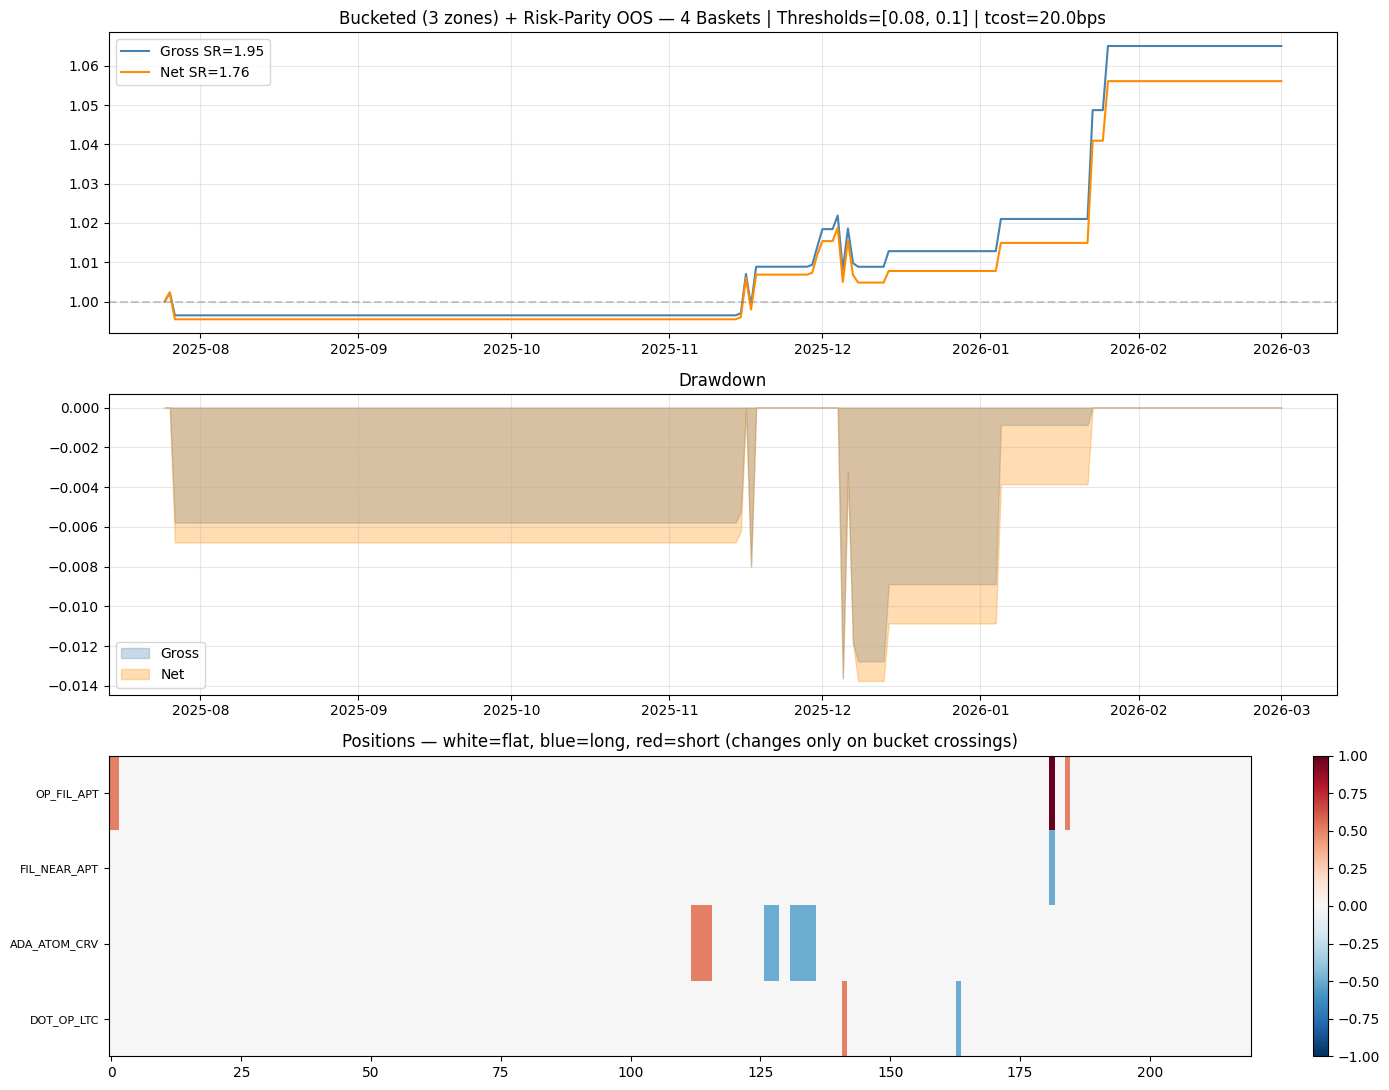

In [36]:
weights_df_b, pos_df_b, gross_pnl_b, net_pnl_b = run_bucketed_filtered_oos(
        prices_test   = prices_test,
        prices_train  = prices_train,
        fold_records  = fold_records_hyst,
        selected_keys = diversified_df["basket"].tolist(),
        exit_thresh   = EXIT_THRESHOLD,
        tcost_bps     = TCOST_BPS,
    )

### 10. Market Neutrality Analysis

Evaluated market neutrality to ensure that the strategy’s returns are driven by **relative value (spread dynamics)** rather than broad market movements. Since the baskets are constructed using cointegration, they are theoretically hedged, but in practice, **residual exposure to market direction can still remain** due to imperfect weights, regime shifts, or dynamic rebalancing.

In [37]:
# ── 1. Net market beta regression ────────────────────────────────────────────
btc_ret = np.log(prices["BTCUSDT"]).diff().reindex(net_pnl_b.index).fillna(0)
eth_ret = np.log(prices["ETHUSDT"]).diff().reindex(net_pnl_b.index).fillna(0)

# Regress net PnL on BTC and ETH returns
X = sm.add_constant(pd.DataFrame({"BTC": btc_ret, "ETH": eth_ret}))
y = net_pnl_b

ols = sm.OLS(y, X).fit()
print(ols.summary())
print(f"\nBTC beta : {ols.params['BTC']:.4f}  (t={ols.tvalues['BTC']:.2f})")
print(f"ETH beta : {ols.params['ETH']:.4f}  (t={ols.tvalues['ETH']:.2f})")
print(f"Alpha (daily) : {ols.params['const']:.6f}  (t={ols.tvalues['const']:.2f})")
print(f"R-squared : {ols.rsquared:.4f}")

# ── 2. Rolling beta (60-day) to see if exposure is stable or drifting ────────
rolling_beta_btc = []
for i in range(60, len(net_pnl_b)):
    window_pnl = net_pnl_b.iloc[i-60:i]
    window_btc = btc_ret.iloc[i-60:i]
    X_w = sm.add_constant(window_btc)
    try:
        b = sm.OLS(window_pnl, X_w).fit().params["BTCUSDT"]
    except Exception:
        b = np.nan
    rolling_beta_btc.append((net_pnl_b.index[i], b))

rolling_beta_btc = pd.Series(
    [x[1] for x in rolling_beta_btc],
    index=[x[0] for x in rolling_beta_btc]
)

# ── 3. Correlation of daily PnL with broad alt market ────────────────────────
# Build equal-weight alt index from your universe (excl BTC/ETH)
alt_cols = [c for c in prices.columns if c not in ("BTCUSDT", "ETHUSDT")]
alt_ret = np.log(prices[alt_cols]).diff().mean(axis=1).reindex(net_pnl_b.index)

print(f"\nCorr(PnL, BTC ret)  : {net_pnl_b.corr(btc_ret):.3f}")
print(f"Corr(PnL, ETH ret)  : {net_pnl_b.corr(eth_ret):.3f}")
print(f"Corr(PnL, Alt index): {net_pnl_b.corr(alt_ret):.3f}")

# ── 4. PnL decomposition: up-market vs down-market days ──────────────────────
btc_up   = net_pnl_b[btc_ret > 0]
btc_down = net_pnl_b[btc_ret <= 0]

print(f"\nMean PnL on BTC-up days   : {btc_up.mean():.6f}  (n={len(btc_up)})")
print(f"Mean PnL on BTC-down days : {btc_down.mean():.6f}  (n={len(btc_down)})")
print(f"Ratio (down/up)           : {btc_down.mean()/btc_up.mean():.2f}x")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.3017
Date:                Fri, 20 Mar 2026   Prob (F-statistic):              0.740
Time:                        12:16:24   Log-Likelihood:                 987.68
No. Observations:                 220   AIC:                            -1969.
Df Residuals:                     217   BIC:                            -1959.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.440      0.1

`Key Takeaways`
- The regression results indicate that the strategy has **negligible exposure to major market factors** with both BTC and ETH betas close to zero and statistically insignificant.  
- The very low R² confirms that **portfolio returns are not explained by broad market movements** but are instead driven by relative value dynamics within the baskets.  
- The near-zero correlations between PnL and BTC, ETH, and the altcoin index further reinforce that the strategy is **effectively market neutral in practice**.  
- The estimated alpha is positive but not statistically significant — this is primarily a **sample size problem** rather than evidence of a weak edge. With only 220 OOS days, there simply aren't enough observations to confirm the signal yet.  
- There’s some asymmetry in up vs down markets, but given the effective sample size and dependence across trades, I wouldn’t treat it as statistically significant without further testing.
- The observed Sharpe of 1.76 is built on only 9 round-trip trades and is therefore **not statistically meaningful** at this stage. Several dozen independent trades at minimum would be needed before the Sharpe ratio becomes a reliable indicator of true edge.